In [42]:
import pandas as pd 
import numpy as np
from pathlib import Path

In [43]:
path_user_listening_hist = Path.cwd().parent / 'data' /'User Listening History.csv'
path_music_info= Path.cwd().parent / 'data' /'cleaned_data.csv'
df = pd.read_csv(path_user_listening_hist)
df.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [44]:
df['user_id'].nunique()

962037

In [45]:
df.groupby(['track_id','user_id'])['playcount'].sum().reset_index()

,track_id,user_id,playcount
0,TRAAAED128E0783FAB,00a8fbf73704eacb620f1eb609df54b2e84a561f,1
1,TRAAAED128E0783FAB,00ca1b72c6236cab83f649ae16cef15b047d1aad,2
2,TRAAAED128E0783FAB,00f6253db355878da9fe32fc78cc560cea8fd7ff,5
3,TRAAAED128E0783FAB,012a06769006d9abdb7e6932fbc666635d44f443,2
4,TRAAAED128E0783FAB,01f93ae419fbba37a2989ef8ddda07170d6c58d4,8
...,...,...,...
9711296,TRZZZRJ128F42819AF,feca90d6d9210159700102cd39666fc4024ee705,1
9711297,TRZZZRJ128F42819AF,ff54da6417dc0a5fec81ad75dd7d31f9ed9d9652,1
9711298,TRZZZRJ128F42819AF,ff85957ab0e44ac6b9d1a88584c11a3a491414d9,4
9711299,TRZZZRJ128F42819AF,ff997409e4fbaa2fcb0dc32c3b4973814c84a68b,1


In [46]:
df_music_info = pd.read_csv(path_music_info)
df_music_info.head()

,track_id,name,artist,spotify_preview_url,tags,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,mr. brightside,the killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,"rock, alternative, indie, alternative_rock, in...",2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,wonderwall,oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,"rock, alternative, indie, pop, alternative_roc...",2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,come as you are,nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,"rock, alternative, alternative_rock, 90s, grunge",1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,take me out,franz ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,"rock, alternative, indie, alternative_rock, in...",2004,237026,0.279,0.664,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,creep,radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,"rock, alternative, indie, alternative_rock, in...",2008,238640,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [47]:
df_music_info['track_id'].nunique()

50674

In [48]:
!pip install kagglehub --upgrade

In [49]:
import kagglehub

In [50]:
# download the dataset from kaggle

kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

'C:\\Users\\amrpu\\.cache\\kagglehub\\datasets\\undefinenull\\million-song-dataset-spotify-lastfm\\versions\\1'

In [51]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
data_path = Path.cwd().parent / 'data' 
songs_data_path = data_path / 'Music Info.csv'
users_data_path = data_path / 'User Listening History.csv'

In [53]:
# songs_data

songs_df = pd.read_csv(songs_data_path, usecols=["track_id","name","artist","spotify_preview_url"])

songs_df.head()

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...


In [54]:
!pip install dask[dataframe]

In [55]:
import dask.dataframe as dd

# Load the dataset
df = dd.read_csv(users_data_path)

# Check the first few rows to verify the data
df.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


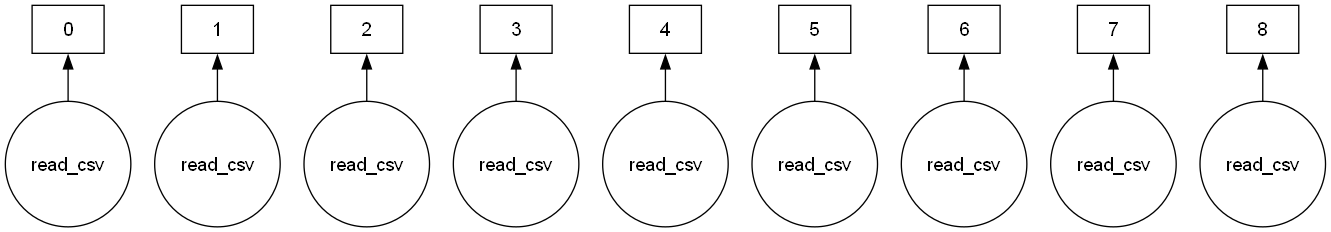

In [56]:
df.visualize(tasks=True)

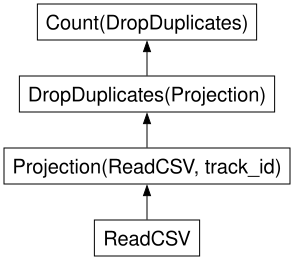

In [57]:
unique_tracks.visualize()

In [ ]:
# no of unique tracks in the data 

unique_tracks = df.loc[:,"track_id"].nunique()
unique_tracks = unique_tracks.compute()
unique_tracks

30459

In [61]:
# number of unique users in the data

unique_users = df.loc[:,"user_id"].nunique()
unique_users = unique_users.compute()
unique_users

962037

In [63]:
# list of unique track_ids

unique_track_ids = df.loc[:,"track_id"].unique().compute()

unique_track_ids = unique_track_ids.tolist()

In [65]:
filter_song = songs_df[songs_df["track_id"].isin(unique_track_ids)]
filter_song

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
7,TRXOGZT128F424AD74,Karma Police,Radiohead,https://p.scdn.co/mp3-preview/5a09f5390e2862af...
9,TRUJIIV12903CA8848,Clocks,Coldplay,https://p.scdn.co/mp3-preview/24c7fe858b234e3c...
...,...,...,...,...
50675,TRXWSIN128F9339A11,Infinite Love Song,Maximilian Hecker,https://p.scdn.co/mp3-preview/8b3d529025fe3c60...
50677,TRPIGDW12903CDEB2D,Slip of the Lip,Fact,https://p.scdn.co/mp3-preview/cf64490291f9a600...
50678,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...
50679,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...


In [66]:
import dask.dataframe as dd
import numpy as np
from scipy.sparse import csr_matrix

In [67]:
df = dd.read_csv(users_data_path)

In [68]:
type(df)

dask_expr._collection.DataFrame

In [69]:
# strep plycount numeric
df['playcount'] = df['playcount'].astype(np.float64)
df = df.categorize(columns=['user_id', 'track_id'])

# Step 3: Convert user_id and track_id to numeric indices
# This is necessary for creating a sparse matrix later
user_mapping = df['user_id'].cat.codes
track_mapping = df['track_id'].cat.codes

df = df.assign(
    user_idx=user_mapping,
    track_idx=track_mapping
)

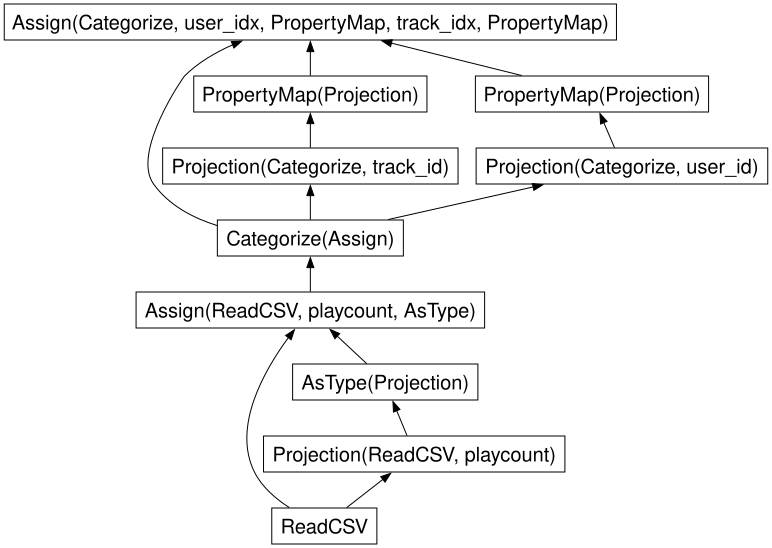

In [70]:
df.visualize()

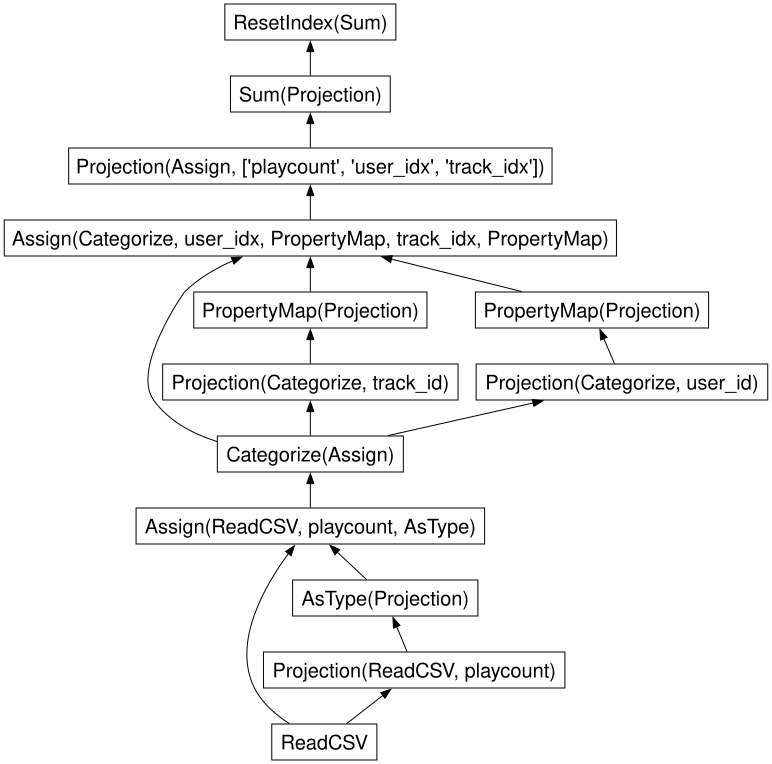

In [71]:
# Step 4 : Compute the interaction matrix

interaction_array = df.groupby(['user_idx', 'track_idx'])['playcount'].sum().reset_index()
interaction_array.visualize()

In [72]:
interaction_array

,user_idx,track_idx,playcount
npartitions=1,,,
,int32,int16,float64
,...,...,...


In [73]:
interaction_array = interaction_array.compute()
interaction_array

In [74]:
interaction_array

,user_idx,track_idx,playcount
0,6,9505,1.0
1,6,28198,1.0
2,9,890,1.0
3,9,3455,1.0
4,9,16921,1.0
...,...,...,...
9711296,962028,29561,1.0
9711297,962028,30104,1.0
9711298,962033,8453,1.0
9711299,962033,18651,1.0


In [75]:
# step5 Create a sparse matrix
# collect the data into a numpy-friendly format

row_indices = interaction_array['track_idx']
col_indices = interaction_array['user_idx']
values = interaction_array['playcount']

In [77]:
# build the sparse matrix
n_tracks = unique_tracks
n_users = unique_users

sparse_matrix = csr_matrix((values, (row_indices, col_indices)), shape=(n_tracks, n_users))

print("Sparse matrix shape:", sparse_matrix.shape)
print("Sparse matrix size:", sparse_matrix.nnz)

Sparse matrix shape: (30459, 962037)
Sparse matrix size: 9711301


In [78]:
((sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]))*100)

0.033141335019756815

In [79]:
from sklearn.metrics.pairwise import cosine_similarity

In [80]:
np.where(df['track_id'].cat.categories == "TROINZB128F932F740")

(array([17018], dtype=int64),)

In [81]:
input_array = sparse_matrix[17018]

In [82]:
similarity_scores = cosine_similarity( input_array,sparse_matrix)

In [91]:
np.sort(similarity_scores).ravel()[-6:-1][::-1]

array([0.08225488, 0.07217127, 0.05592032, 0.05529279, 0.05404559])

In [93]:
np.argsort(similarity_scores.ravel())[-6:-1][::-1]

array([24529, 28964,  3620,  9470,  7882], dtype=int64)

In [94]:
recommendations = df['track_id'].cat.categories[np.argsort(similarity_scores.ravel())[-6:][::-1]]
recommendations

Index(['TROINZB128F932F740', 'TRURCEI12903CA4395', 'TRYLWIW12903CA438D',
       'TRCVMAF12903D00E61', 'TRHRNEE12903CFDBD4', 'TRGEUXY128F4226B26'],
      dtype='object', name='track_id')

In [96]:
filter_song[filter_song["track_id"].isin(recommendations)]

,track_id,name,artist,spotify_preview_url
6013,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...
15899,TRCVMAF12903D00E61,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...
29724,TRGEUXY128F4226B26,Monday Massacre,Mr. Oizo,https://p.scdn.co/mp3-preview/4d6dbacc93e3ef7e...
44767,TRYLWIW12903CA438D,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...
44917,TRURCEI12903CA4395,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...
46566,TRHRNEE12903CFDBD4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...


In [97]:
songs_df

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...
...,...,...,...,...
50678,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...
50679,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...
50680,TRZRODK128F92D68D7,The Revelation,coldrain,https://p.scdn.co/mp3-preview/4b51a813f67e3853...
50681,TRGLMEM128F9322F63,Koi no Dependence,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/5a61e031df174666...
